# IT549: Deep Learning
## Lab Assignment 4: Object Detection Evolution — From R-CNN to YOLO

**Dataset:** Fruit Images for Object Detection (Apple, Banana, Orange)  
**Source:** [Kaggle – mbkinaci/fruit-images-for-object-detection](https://www.kaggle.com/datasets/mbkinaci/fruit-images-for-object-detection/data)

---

### Objective
This lab walks through the evolution of object detection architectures — from region-proposal based methods (R-CNN, Fast R-CNN, Faster R-CNN) to the single-pass YOLO family — while providing hands-on implementation experience with each major paradigm shift.

---

### ⚙️ Runtime Setup
Before running, go to **Runtime → Change runtime type → T4 GPU** (free tier).  
Your dataset folder structure on Drive should be:
```
MyDrive/
  data/
    train/
        apple_1.jpg
        apple_1.xml
        ...
    test/
        apple_77.jpg
        apple_77.xml
        ...
```

## Step 0 — Mount Google Drive & Install Dependencies

In [36]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
# Install required packages
# We remove the "numpy<2" restriction to satisfy newer dependency requirements
!pip install ultralytics opencv-contrib-python pyyaml numpy --quiet
print("Installation complete.")

Installation complete.


## Step 1 — Imports & Device Check

In [38]:
import os
import time
import random
import glob
import shutil
import xml.etree.ElementTree as ET

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yaml

import torch
import torchvision
import torchvision.transforms as T
import torchvision.models as models
import torchvision.ops as ops
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch version : {torch.__version__}")
print(f"Torchvision     : {torchvision.__version__}")
print(f"OpenCV          : {cv2.__version__}")
print(f"Device          : {device}")

PyTorch version : 2.10.0+cu128
Torchvision     : 0.25.0+cu128
OpenCV          : 4.13.0
Device          : cuda


In [39]:
# import os
# # This will restart the Colab runtime session
# os._exit(0)

## Step 2 — Dataset Configuration

**Only change `DATASET_ROOT` below** if your Drive folder path is different.  
Default assumes the folder is at `MyDrive/data`.

In [40]:
# ── CHANGE THIS IF YOUR FOLDER IS ELSEWHERE ON DRIVE ──
DATASET_ROOT = "/content/drive/MyDrive/Fruit Images"

TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
TEST_DIR  = os.path.join(DATASET_ROOT, "test")

# Class mappings
CLASS_NAMES  = {0: "apple", 1: "banana", 2: "orange"}
NAME_TO_ID   = {v: k for k, v in CLASS_NAMES.items()}   # apple→0, etc.
CLASS_COLORS = {
    "apple":  (220,  50,  50),
    "banana": (240, 200,   0),
    "orange": (255, 140,   0),
}

def get_label_path(img_path):
    """Return the .xml annotation path for a given image path."""
    stem = os.path.splitext(img_path)[0]
    return stem + ".xml"

# Collect sorted image lists
all_train_images = sorted(
    glob.glob(os.path.join(TRAIN_DIR, "*.jpg")) +
    glob.glob(os.path.join(TRAIN_DIR, "*.png"))
)
all_test_images = sorted(
    glob.glob(os.path.join(TEST_DIR, "*.jpg")) +
    glob.glob(os.path.join(TEST_DIR, "*.png"))
)

assert len(all_train_images) > 0, f"No images found in {TRAIN_DIR}. Check your DATASET_ROOT path."
assert len(all_test_images)  > 0, f"No images found in {TEST_DIR}. Check your DATASET_ROOT path."

print(f"Training images : {len(all_train_images)}")
print(f"Test images     : {len(all_test_images)}")
print(f"Example         : {os.path.basename(all_train_images[0])}")

Training images : 240
Test images     : 60
Example         : apple_1.jpg


---
## Preparation — Ground Truth Visualization

A random training image is selected, its Pascal VOC XML annotation is parsed, and all ground-truth bounding boxes are drawn using Matplotlib + OpenCV.

In [41]:
def parse_voc_xml(label_path, name_to_id):
    """
    Parse a Pascal VOC XML annotation file.

    Parameters
    ----------
    label_path : str  — path to the .xml file
    name_to_id : dict — e.g. {'apple': 0, 'banana': 1, 'orange': 2}

    Returns
    -------
    list of (class_id, x_min, y_min, x_max, y_max)
    """
    boxes = []
    if not os.path.exists(label_path):
        print(f"  [WARNING] Label not found: {label_path}")
        return boxes
    try:
        root = ET.parse(label_path).getroot()
        for obj in root.findall("object"):
            name = obj.find("name").text.strip().lower()
            if name not in name_to_id:
                continue
            b = obj.find("bndbox")
            x1 = int(float(b.find("xmin").text))
            y1 = int(float(b.find("ymin").text))
            x2 = int(float(b.find("xmax").text))
            y2 = int(float(b.find("ymax").text))
            boxes.append((name_to_id[name], x1, y1, x2, y2))
    except Exception as e:
        print(f"  [ERROR] Failed to parse {label_path}: {e}")
    return boxes


def draw_boxes_on_image(img_bgr, boxes, class_names, class_colors):
    """Draw bounding boxes + class labels on a copy of a BGR image."""
    img = img_bgr.copy()
    for (cls_id, x1, y1, x2, y2) in boxes:
        label = class_names.get(cls_id, str(cls_id))
        color = class_colors.get(label, (0, 255, 0))
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img, label, (x1, max(y1 - 8, 12)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
    return img

Image      : mixed_5.jpg  (1024 x 1024)
Label file : /content/drive/MyDrive/Fruit Images/train/mixed_5.xml
Ground-truth boxes: 3
  class=orange, box=(556, 178, 950, 559)
  class=apple, box=(73, 164, 474, 550)
  class=banana, box=(177, 604, 858, 966)


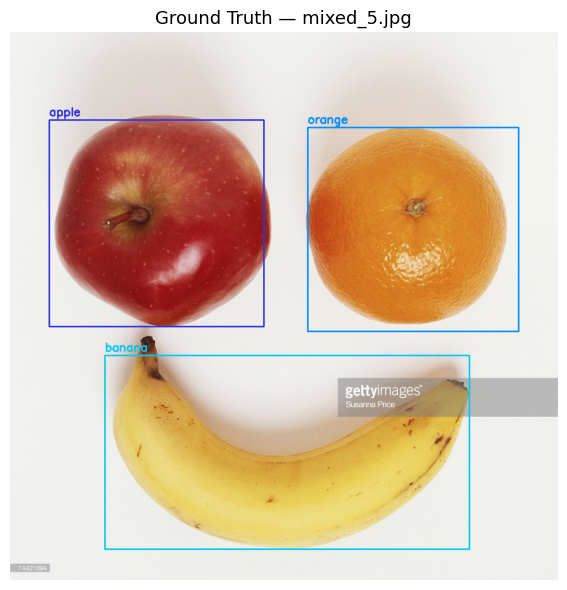

In [42]:
random.seed(42)
sample_img_path   = random.choice(all_train_images)
sample_label_path = get_label_path(sample_img_path)

img_bgr  = cv2.imread(sample_img_path)
img_h, img_w = img_bgr.shape[:2]

print(f"Image      : {os.path.basename(sample_img_path)}  ({img_w} x {img_h})")
print(f"Label file : {sample_label_path}")

gt_boxes = parse_voc_xml(sample_label_path, NAME_TO_ID)
print(f"Ground-truth boxes: {len(gt_boxes)}")
for b in gt_boxes:
    print(f"  class={CLASS_NAMES.get(b[0], b[0])}, box={b[1:]}")

annotated = draw_boxes_on_image(img_bgr, gt_boxes, CLASS_NAMES, CLASS_COLORS)

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title(f"Ground Truth — {os.path.basename(sample_img_path)}", fontsize=13)
plt.axis("off")
plt.tight_layout()
plt.show()

---
## Task 1 — Core Concept: Intersection over Union (IoU)

**IoU** measures how much two bounding boxes overlap:

$$\text{IoU} = \frac{\text{Area of Intersection}}{\text{Area of Union}}$$

A value of **1.0** means perfect overlap; **0.0** means no overlap at all.  
IoU is used in: mAP evaluation, NMS (Task 6), and training-time box matching.

In [43]:
def compute_iou(box_a, box_b):
    """
    Compute Intersection over Union (IoU) between two axis-aligned bounding boxes.

    Parameters
    ----------
    box_a, box_b : list or tuple [x_min, y_min, x_max, y_max]

    Returns
    -------
    float : IoU score in [0.0, 1.0]
    """
    # Intersection rectangle
    ix1 = max(box_a[0], box_b[0])
    iy1 = max(box_a[1], box_b[1])
    ix2 = min(box_a[2], box_b[2])
    iy2 = min(box_a[3], box_b[3])

    inter_area = max(0, ix2 - ix1) * max(0, iy2 - iy1)

    area_a     = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
    area_b     = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])
    union_area = area_a + area_b - inter_area

    return 0.0 if union_area == 0 else inter_area / union_area

In [44]:
# Demonstrate with 3 pairs covering high, partial, and zero overlap
test_cases = [
    ("Highly overlapping",    [10, 10, 100, 100], [15, 15,  95,  95]),
    ("Partially overlapping", [10, 10,  80,  80], [50, 50, 120, 120]),
    ("Completely disjoint",   [10, 10,  50,  50], [60, 60, 100, 100]),
]

print(f"{'Description':<25} {'Box A':<28} {'Box B':<28} {'IoU':>6}")
print("-" * 95)
for desc, ba, bb in test_cases:
    iou = compute_iou(ba, bb)
    print(f"{desc:<25} {str(ba):<28} {str(bb):<28} {iou:>6.4f}")

Description               Box A                        Box B                           IoU
-----------------------------------------------------------------------------------------------
Highly overlapping        [10, 10, 100, 100]           [15, 15, 95, 95]             0.7901
Partially overlapping     [10, 10, 80, 80]             [50, 50, 120, 120]           0.1011
Completely disjoint       [10, 10, 50, 50]             [60, 60, 100, 100]           0.0000


---
## Task 2 — The Baseline: Selective Search (R-CNN Step 1)

**R-CNN** uses **Selective Search** — a classical CPU-based algorithm that groups superpixels based on colour, texture, size, and fill — to generate ~1000-2000 candidate regions per image before any neural network is involved.

In [45]:
img_bgr_ss = cv2.imread(sample_img_path)

# Initialise Selective Search in fast mode
ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
ss.setBaseImage(img_bgr_ss)
ss.switchToSelectiveSearchFast()   # use switchToSelectiveSearchQuality() for higher recall

t0 = time.time()
proposals = ss.process()           # returns array of (x, y, w, h)
ss_time   = time.time() - t0

print(f"Total proposals generated : {len(proposals)}")
print(f"Selective Search runtime  : {ss_time:.3f} s")

proposals_200 = proposals[:200]    # keep top 200

Total proposals generated : 1815
Selective Search runtime  : 15.535 s


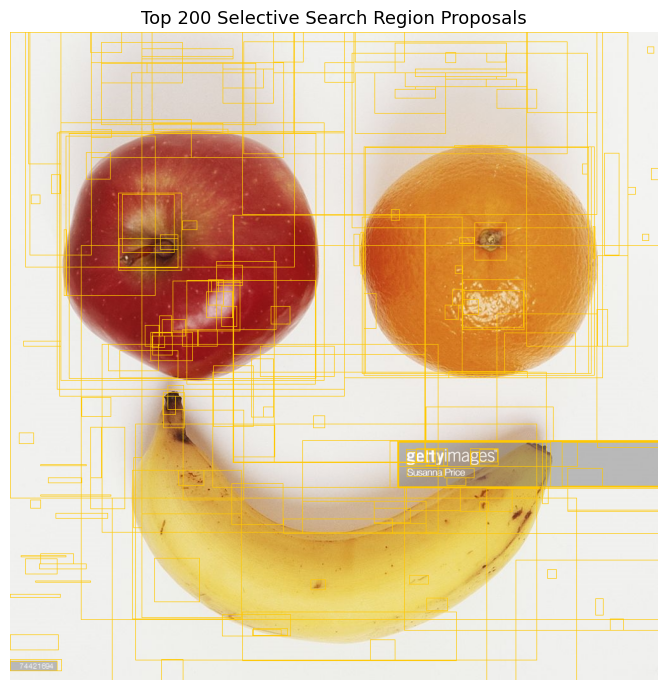

In [46]:
# Visualise the 200 proposals
img_proposals = img_bgr_ss.copy()
for (x, y, w, h) in proposals_200:
    cv2.rectangle(img_proposals, (x, y), (x + w, y + h), (0, 200, 255), 1)

plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(img_proposals, cv2.COLOR_BGR2RGB))
plt.title("Top 200 Selective Search Region Proposals", fontsize=13)
plt.axis("off")
plt.tight_layout()
plt.show()

---
## Task 3 — Implementing the R-CNN Bottleneck

In the original **R-CNN**, every region proposal is:
1. **Cropped** from the raw image
2. **Warped** to a fixed 224×224 size
3. **Forward-passed** through a full CNN *independently*

For 100 proposals this means **100 complete forward passes** — massively redundant because overlapping regions share computation.

In [47]:
# Load ResNet-18 and strip global average pool + FC → pure feature extractor
resnet18_full     = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
feature_extractor = torch.nn.Sequential(*list(resnet18_full.children())[:-1])
feature_extractor.eval().to(device)

crop_transform = T.Compose([
    T.ToPILImage(),
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
])

img_rgb  = cv2.cvtColor(img_bgr_ss, cv2.COLOR_BGR2RGB)
top_100  = proposals_200[:100]

print(f"ResNet-18 feature extractor ready on: {device}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 143MB/s]


ResNet-18 feature extractor ready on: cuda


In [48]:
feature_vectors = []

rcnn_start = time.time()

with torch.no_grad():
    for (x, y, w, h) in top_100:
        x1 = max(0, x)
        y1 = max(0, y)
        x2 = min(img_rgb.shape[1], x + w)
        y2 = min(img_rgb.shape[0], y + h)

        crop = img_rgb[y1:y2, x1:x2]
        if crop.size == 0:
            continue

        tensor = crop_transform(crop).unsqueeze(0).to(device)   # (1, 3, 224, 224)
        feat   = feature_extractor(tensor)                       # (1, 512, 1, 1)
        feature_vectors.append(feat.squeeze().cpu())

rcnn_time = time.time() - rcnn_start

print(f"R-CNN-style processing")
print(f"  Proposals processed       : {len(feature_vectors)}")
print(f"  Total execution time      : {rcnn_time:.4f} s  ({rcnn_time * 1000:.2f} ms)")
print(f"  Average time per crop     : {rcnn_time / max(len(feature_vectors), 1) * 1000:.3f} ms")

R-CNN-style processing
  Proposals processed       : 100
  Total execution time      : 1.2963 s  (1296.35 ms)
  Average time per crop     : 12.963 ms


---
## Task 4 — Implementing Fast R-CNN (RoI Pooling)

**Fast R-CNN** solved Task 3's bottleneck by:
- Passing the **entire image** through the CNN **once** → shared feature map
- Extracting per-proposal features via **RoI Pooling** directly from that shared map

### Spatial Scale
ResNet-18's conv body down-samples by **32×** (conv1 stride-2 + maxpool stride-2 + layers 2/3/4 each stride-2 = 5 halvings).  
→ `spatial_scale = 1 / 32 = 0.03125`

In [49]:
# Build conv body (everything except global avg pool and FC)
conv_body = torch.nn.Sequential(
    resnet18_full.conv1,
    resnet18_full.bn1,
    resnet18_full.relu,
    resnet18_full.maxpool,
    resnet18_full.layer1,
    resnet18_full.layer2,
    resnet18_full.layer3,
    resnet18_full.layer4,
).eval().to(device)

full_img_tf = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
])

img_tensor = full_img_tf(img_rgb).unsqueeze(0).to(device)   # (1, 3, H, W)
print(f"Full image tensor shape : {img_tensor.shape}")

Full image tensor shape : torch.Size([1, 3, 1024, 1024])


In [50]:
SPATIAL_SCALE   = 1 / 32.0
ROI_OUTPUT_SIZE = 7

fast_rcnn_start = time.time()

with torch.no_grad():
    # Step 1 — Single CNN forward pass over the full image
    feature_map = conv_body(img_tensor)    # (1, 512, H/32, W/32)

    # Step 2 — Build RoI tensor [batch_idx, x1, y1, x2, y2]
    roi_list = []
    for (x, y, w, h) in top_100:
        x1 = max(0.0, float(x))
        y1 = max(0.0, float(y))
        x2 = min(float(img_rgb.shape[1]), float(x + w))
        y2 = min(float(img_rgb.shape[0]), float(y + h))
        roi_list.append([0, x1, y1, x2, y2])
    roi_tensor = torch.tensor(roi_list, dtype=torch.float32).to(device)

    # Step 3 — RoI Pooling
    pooled = ops.roi_pool(
        feature_map,
        roi_tensor,
        output_size=ROI_OUTPUT_SIZE,
        spatial_scale=SPATIAL_SCALE,
    )   # (100, 512, 7, 7)

fast_rcnn_time = time.time() - fast_rcnn_start

print(f"Fast R-CNN pipeline")
print(f"  Feature map shape   : {feature_map.shape}")
print(f"  Pooled output shape : {pooled.shape}")
print(f"  Spatial scale       : {SPATIAL_SCALE}  (stride = 32)")
print()
print(f"  Total execution time: {fast_rcnn_time:.4f} s  ({fast_rcnn_time * 1000:.2f} ms)")
print()
print("── Speed Comparison ──")
print(f"  R-CNN   (Task 3)    : {rcnn_time * 1000:.2f} ms")
print(f"  Fast R-CNN (Task 4) : {fast_rcnn_time * 1000:.2f} ms")
speedup = rcnn_time / fast_rcnn_time if fast_rcnn_time > 0 else float('inf')
print(f"  Speedup             : {speedup:.1f}x")

Fast R-CNN pipeline
  Feature map shape   : torch.Size([1, 512, 32, 32])
  Pooled output shape : torch.Size([100, 512, 7, 7])
  Spatial scale       : 0.03125  (stride = 32)

  Total execution time: 0.0335 s  (33.47 ms)

── Speed Comparison ──
  R-CNN   (Task 3)    : 1296.35 ms
  Fast R-CNN (Task 4) : 33.47 ms
  Speedup             : 38.7x


### Conceptual Analysis — Task 4

> **Q: Based on your recorded execution times, what redundant mathematical operations does Fast R-CNN eliminate to achieve this efficiency?**

In the original R-CNN approach (Task 3), every one of the 100 region proposals is cropped from the raw image, resized to 224×224, and then individually passed through **all convolutional layers** of ResNet-18. Because many proposals overlap spatially, the same pixel regions are processed by the CNN multiple times — leading to massive **redundant computation**.

Fast R-CNN eliminates this redundancy by applying the convolutional layers **exactly once** to the full image, producing a single shared feature map. The expensive convolutional operations (multiply-accumulate across each filter at every spatial position) are therefore performed only once, regardless of how many region proposals exist. The subsequent **RoI Pooling** step is computationally trivial by comparison — it simply applies max-pooling to extract a fixed-size grid from an already-computed feature map, with no weight multiplications involved.

In short, Fast R-CNN removes the N-fold redundancy in convolutional feature extraction by decoupling *feature computation* (done once) from *region-specific pooling* (done N times cheaply).

---
## Task 5 — Faster R-CNN

**Faster R-CNN** replaces the external Selective Search with a learned **Region Proposal Network (RPN)** that shares the backbone — making proposals essentially free in compute terms.

In [51]:
faster_rcnn_model = fasterrcnn_resnet50_fpn(
    weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT
).eval().to(device)

# COCO class index → name  (index 0 = background)
COCO_CLASSES = [
    "__background__",
    "person","bicycle","car","motorcycle","airplane","bus","train","truck",
    "boat","traffic light","fire hydrant","stop sign","parking meter","bench",
    "bird","cat","dog","horse","sheep","cow","elephant","bear","zebra",
    "giraffe","backpack","umbrella","handbag","tie","suitcase","frisbee",
    "skis","snowboard","sports ball","kite","baseball bat","baseball glove",
    "skateboard","surfboard","tennis racket","bottle","wine glass","cup",
    "fork","knife","spoon","bowl","banana","apple","sandwich","orange",
    "broccoli","carrot","hot dog","pizza","donut","cake","chair","couch",
    "potted plant","bed","dining table","toilet","tv","laptop","mouse",
    "remote","keyboard","cell phone","microwave","oven","toaster","sink",
    "refrigerator","book","clock","vase","scissors","teddy bear","hair drier",
    "toothbrush",
]

print("Faster R-CNN (ResNet-50 + FPN) loaded successfully.")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 178MB/s]


Faster R-CNN (ResNet-50 + FPN) loaded successfully.


In [52]:
CONF_THRESHOLD = 0.80

def filter_predictions(preds, threshold):
    """Keep only detections whose confidence score >= threshold."""
    keep = preds["scores"] >= threshold
    return {k: v[keep] for k, v in preds.items()}

to_tensor_fn     = T.ToTensor()
img_tensor_frcnn = to_tensor_fn(img_rgb).to(device)

with torch.no_grad():
    raw_preds = faster_rcnn_model([img_tensor_frcnn])[0]

filtered = filter_predictions(raw_preds, CONF_THRESHOLD)

print(f"Raw predictions          : {len(raw_preds['scores'])}")
print(f"After filtering >= {CONF_THRESHOLD} : {len(filtered['scores'])}")
print()
for box, lbl, score in zip(filtered["boxes"], filtered["labels"], filtered["scores"]):
    cls_name = COCO_CLASSES[lbl.item()] if lbl.item() < len(COCO_CLASSES) else str(lbl.item())
    print(f"  {cls_name:<15} score={score:.3f}  box={[round(v) for v in box.tolist()]}")

Raw predictions          : 6
After filtering >= 0.8 : 3

  carrot          score=0.998  box=[199, 564, 858, 965]
  donut           score=0.995  box=[549, 179, 935, 553]
  hot dog         score=0.985  box=[78, 148, 493, 552]


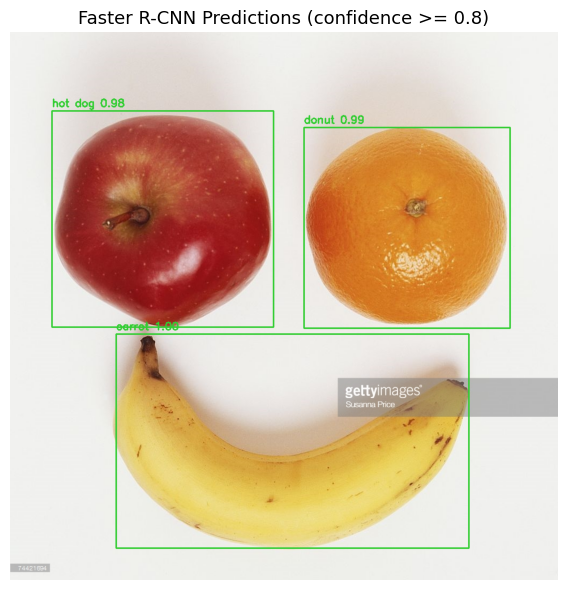

In [53]:
# Visualise Faster R-CNN predictions
vis_frcnn = img_rgb.copy()
for box, lbl, score in zip(filtered["boxes"], filtered["labels"], filtered["scores"]):
    x1, y1, x2, y2 = map(int, box.tolist())
    cls_name  = COCO_CLASSES[lbl.item()] if lbl.item() < len(COCO_CLASSES) else str(lbl.item())
    label_str = f"{cls_name} {score:.2f}"
    cv2.rectangle(vis_frcnn, (x1, y1), (x2, y2), (50, 205, 50), 2)
    cv2.putText(vis_frcnn, label_str, (x1, max(y1 - 8, 12)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.65, (50, 205, 50), 2)

plt.figure(figsize=(9, 6))
plt.imshow(vis_frcnn)
plt.title(f"Faster R-CNN Predictions (confidence >= {CONF_THRESHOLD})", fontsize=13)
plt.axis("off")
plt.tight_layout()
plt.show()

### Conceptual Analysis — Task 5

> **Q: How does the RPN eliminate the need for external algorithms like Selective Search?**

Selective Search is a **hand-crafted, CPU-bound** algorithm that groups image superpixels using heuristic rules (colour histograms, texture gradients, etc.). It operates entirely independently of the detection network and cannot be trained end-to-end.

The **Region Proposal Network (RPN)** in Faster R-CNN replaces this with a **learned, GPU-accelerated** module. The RPN slides a small network over the shared convolutional feature map produced by the backbone. At each spatial location it evaluates a set of predefined **anchor boxes** at multiple scales and aspect ratios, predicting two things per anchor:
1. **Objectness score** — probability that the anchor contains any object
2. **Box regression offsets** — how to adjust the anchor coordinates to better fit the object boundary

Because the RPN reads from the **same feature map** already computed for the detection head, it adds almost no extra computation. More importantly, it is **trained jointly** with the detector, so it learns to propose regions that are specifically useful for the downstream classification task — something Selective Search, being purely unsupervised and heuristic-driven, can never do.

---
## Task 6 — Non-Maximum Suppression (NMS)

Object detectors produce many overlapping predictions for the same object. **NMS** prunes duplicates:
1. Sort all boxes by confidence (highest first)
2. Greedily select the top-scoring box
3. Discard any remaining box with IoU > threshold relative to the selected box
4. Repeat until no boxes remain

In [54]:
def non_maximum_suppression(boxes, scores, iou_threshold=0.5):
    """
    Custom NMS implementation using compute_iou() from Task 1.

    Parameters
    ----------
    boxes         : list of [x_min, y_min, x_max, y_max]
    scores        : list of float confidence scores
    iou_threshold : boxes with IoU > this value are suppressed

    Returns
    -------
    kept_boxes, kept_scores : filtered lists
    """
    if not boxes:
        return [], []

    # Sort indices by score — descending
    order = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)

    kept_indices = []
    while order:
        best  = order[0]               # highest-scoring remaining box
        kept_indices.append(best)
        order = order[1:]              # remove from candidates

        # Discard candidates that overlap too much with `best`
        order = [i for i in order
                 if compute_iou(boxes[best], boxes[i]) <= iou_threshold]

    kept_boxes  = [boxes[i]  for i in kept_indices]
    kept_scores = [scores[i] for i in kept_indices]
    return kept_boxes, kept_scores

Boxes before NMS : 7
Boxes after  NMS : 2  (IoU threshold = 0.5)
  score=0.95  box=[50, 50, 200, 200]
  score=0.92  box=[300, 100, 480, 280]


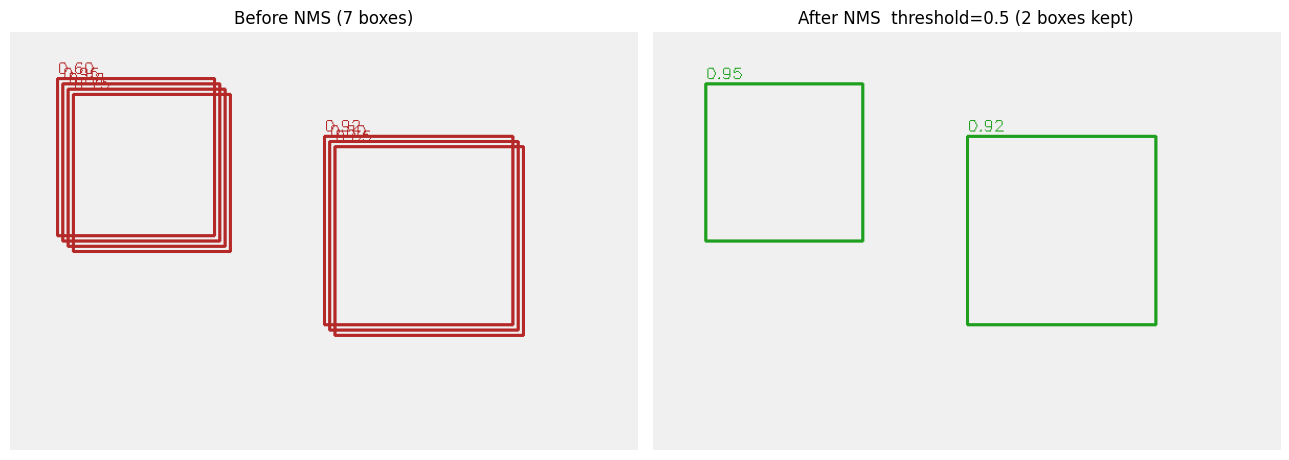

In [55]:
# Synthetic boxes simulating multiple detections for 2 objects
demo_boxes = [
    [ 50,  50, 200, 200],   # object 1 cluster
    [ 55,  55, 205, 205],
    [ 60,  60, 210, 210],
    [ 45,  45, 195, 195],
    [300, 100, 480, 280],   # object 2 cluster
    [305, 105, 485, 285],
    [310, 110, 490, 290],
]
demo_scores = [0.95, 0.88, 0.75, 0.60, 0.92, 0.80, 0.65]

IOU_THRESH = 0.5
kept_boxes, kept_scores = non_maximum_suppression(demo_boxes, demo_scores, IOU_THRESH)

print(f"Boxes before NMS : {len(demo_boxes)}")
print(f"Boxes after  NMS : {len(kept_boxes)}  (IoU threshold = {IOU_THRESH})")
for box, score in zip(kept_boxes, kept_scores):
    print(f"  score={score:.2f}  box={box}")

# Visualisation
canvas_b = np.ones((400, 600, 3), dtype=np.uint8) * 240
canvas_a = np.ones((400, 600, 3), dtype=np.uint8) * 240

for box, score in zip(demo_boxes, demo_scores):
    x1, y1, x2, y2 = box
    cv2.rectangle(canvas_b, (x1, y1), (x2, y2), (180, 40, 40), 2)
    cv2.putText(canvas_b, f"{score:.2f}", (x1, max(y1 - 5, 10)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (180, 40, 40), 1)

for box, score in zip(kept_boxes, kept_scores):
    x1, y1, x2, y2 = box
    cv2.rectangle(canvas_a, (x1, y1), (x2, y2), (30, 160, 30), 2)
    cv2.putText(canvas_a, f"{score:.2f}", (x1, max(y1 - 5, 10)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (30, 160, 30), 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(canvas_b)
axes[0].set_title(f"Before NMS ({len(demo_boxes)} boxes)", fontsize=12)
axes[0].axis("off")
axes[1].imshow(canvas_a)
axes[1].set_title(f"After NMS  threshold={IOU_THRESH} ({len(kept_boxes)} boxes kept)", fontsize=12)
axes[1].axis("off")
plt.tight_layout()
plt.show()

### Conceptual Analysis — Task 6

> **Q: If you are detecting a cluster of tightly packed objects (e.g., several apples in a basket), how would an IoU threshold of 0.9 vs 0.1 affect your predictions?**

**High IoU threshold (0.9 — lenient suppression):**  
A box is only discarded if it overlaps the selected box by 90% or more. Adjacent apple boxes typically overlap well under 90%, so NMS **keeps most boxes**, allowing each apple its own detection. The downside: near-duplicate boxes for the *same* apple (very high IoU) also survive, flooding the output.

**Low IoU threshold (0.1 — aggressive suppression):**  
A box is discarded with just 10% overlap. In a dense cluster, neighbouring apple boxes naturally exceed 10% overlap. NMS will **suppress real detections**, collapsing the entire cluster to a single box and causing severe under-counting.

**Conclusion:** For tightly packed objects use a **higher threshold (0.5–0.7)** to preserve distinct detections. For well-separated objects a lower threshold cleanly removes duplicates. Modern detectors (e.g., Soft-NMS) use adaptive strategies rather than a hard cutoff to handle both scenarios gracefully.

---
## Task 7 — YOLO Fine-Tuning

**YOLO** (You Only Look Once) divides the image into a grid and predicts bounding boxes and class probabilities in a **single forward pass** — no region proposals at all.

### Step 7a — Prepare YOLO Dataset Structure

YOLOv8 (Ultralytics) expects:
- Images in `split/images/`
- Labels in `split/labels/` as `.txt` (one line per box: `class_id xc yc w h` normalised)

The cell below converts your Pascal VOC XML annotations to YOLO format and organises the directory.

In [56]:
# YOLO dataset will be created inside /content (fast local SSD, not Drive)
YOLO_ROOT = "/content/yolo_dataset"

def prepare_yolo_split(src_dir, split_name):
    """
    Copy images and convert Pascal VOC XML labels → YOLO .txt format.
    Images with width=0 in XML are handled by reading actual image dimensions.
    """
    img_out = os.path.join(YOLO_ROOT, split_name, "images")
    lbl_out = os.path.join(YOLO_ROOT, split_name, "labels")
    os.makedirs(img_out, exist_ok=True)
    os.makedirs(lbl_out, exist_ok=True)

    imgs = sorted(
        glob.glob(os.path.join(src_dir, "*.jpg")) +
        glob.glob(os.path.join(src_dir, "*.png"))
    )
    copied, skipped = 0, 0

    for img_path in imgs:
        stem      = os.path.splitext(img_path)[0]
        base      = os.path.basename(img_path)
        label_src = stem + ".xml"

        if not os.path.exists(label_src):
            skipped += 1
            continue

        # Use actual image dimensions (XML may have width=0)
        img = cv2.imread(img_path)
        if img is None:
            skipped += 1
            continue
        img_h, img_w = img.shape[:2]

        try:
            root = ET.parse(label_src).getroot()
            yolo_lines = []
            for obj in root.findall("object"):
                name = obj.find("name").text.strip().lower()
                if name not in NAME_TO_ID:
                    continue
                cls_id = NAME_TO_ID[name]
                b = obj.find("bndbox")
                xmin = float(b.find("xmin").text)
                ymin = float(b.find("ymin").text)
                xmax = float(b.find("xmax").text)
                ymax = float(b.find("ymax").text)

                # Convert to YOLO normalised format
                w_box = (xmax - xmin) / img_w
                h_box = (ymax - ymin) / img_h
                xc    = xmin / img_w + w_box / 2
                yc    = ymin / img_h + h_box / 2

                # Clamp to [0, 1]
                xc    = max(0.0, min(1.0, xc))
                yc    = max(0.0, min(1.0, yc))
                w_box = max(0.0, min(1.0, w_box))
                h_box = max(0.0, min(1.0, h_box))

                yolo_lines.append(f"{cls_id} {xc:.6f} {yc:.6f} {w_box:.6f} {h_box:.6f}")
        except Exception as e:
            print(f"Skipping {label_src}: {e}")
            skipped += 1
            continue

        shutil.copy2(img_path, os.path.join(img_out, base))
        lbl_name = os.path.splitext(base)[0] + ".txt"
        with open(os.path.join(lbl_out, lbl_name), "w") as f:
            f.write("\n".join(yolo_lines))
        copied += 1

    print(f"  [{split_name:<5}] copied/converted={copied}  skipped={skipped}")


print("Preparing YOLO dataset structure (copying from Drive to /content)...")
prepare_yolo_split(TRAIN_DIR, "train")
prepare_yolo_split(TEST_DIR,  "val")
print(f"\nDone. YOLO dataset at: {YOLO_ROOT}")

Preparing YOLO dataset structure (copying from Drive to /content)...
  [train] copied/converted=240  skipped=0
  [val  ] copied/converted=60  skipped=0

Done. YOLO dataset at: /content/yolo_dataset


In [57]:
# Write data.yaml required by Ultralytics
data_yaml = {
    "path" : YOLO_ROOT,
    "train": "train/images",
    "val"  : "val/images",
    "test" : "val/images",
    "nc"   : 3,
    "names": ["apple", "banana", "orange"],
}

yaml_path = os.path.join(YOLO_ROOT, "data.yaml")
with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print("data.yaml written:")
print(yaml.dump(data_yaml))

data.yaml written:
names:
- apple
- banana
- orange
nc: 3
path: /content/yolo_dataset
test: val/images
train: train/images
val: val/images



### Step 7b — Fine-Tune YOLOv8n (10 epochs)

In [58]:
from ultralytics import YOLO

yolo_model = YOLO("yolov8n.pt")   # downloads pre-trained nano weights

train_results = yolo_model.train(
    data    = yaml_path,
    epochs  = 10,
    imgsz   = 640,
    batch   = 16,
    name    = "fruit_yolov8n",
    device  = 0 if torch.cuda.is_available() else "cpu",
    verbose = True,
)

print("\nTraining complete!")
print(f"Best weights saved at: {yolo_model.trainer.best}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int

### Step 7c — Evaluate Fine-Tuned Model

In [59]:
best_weights   = yolo_model.trainer.best
finetuned_yolo = YOLO(best_weights)

ft_metrics = finetuned_yolo.val(data=yaml_path, split="test", verbose=False)

map50   = ft_metrics.box.map50
map5095 = ft_metrics.box.map
ft_prec = ft_metrics.box.mp
ft_rec  = ft_metrics.box.mr

print("Fine-tuned YOLOv8n — Test Set Metrics")
print(f"  mAP@50     : {map50:.4f}")
print(f"  mAP@50-95  : {map5095:.4f}")
print(f"  Precision  : {ft_prec:.4f}")
print(f"  Recall     : {ft_rec:.4f}")

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1230.4±511.7 MB/s, size: 42.7 KB)
val: Scanning /content/yolo_dataset/val/labels.cache... 60 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 60/60 25.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.8it/s 2.3s
                   all         60        117      0.806      0.856      0.892      0.664
Speed: 7.1ms preprocess, 13.8ms inference, 0.0ms loss, 5.8ms postprocess per image
Results saved to /content/runs/detect/val
Fine-tuned YOLOv8n — Test Set Metrics
  mAP@50     : 0.8917
  mAP@50-95  : 0.6635
  Precision  : 0.8063
  Recall     : 0.8565


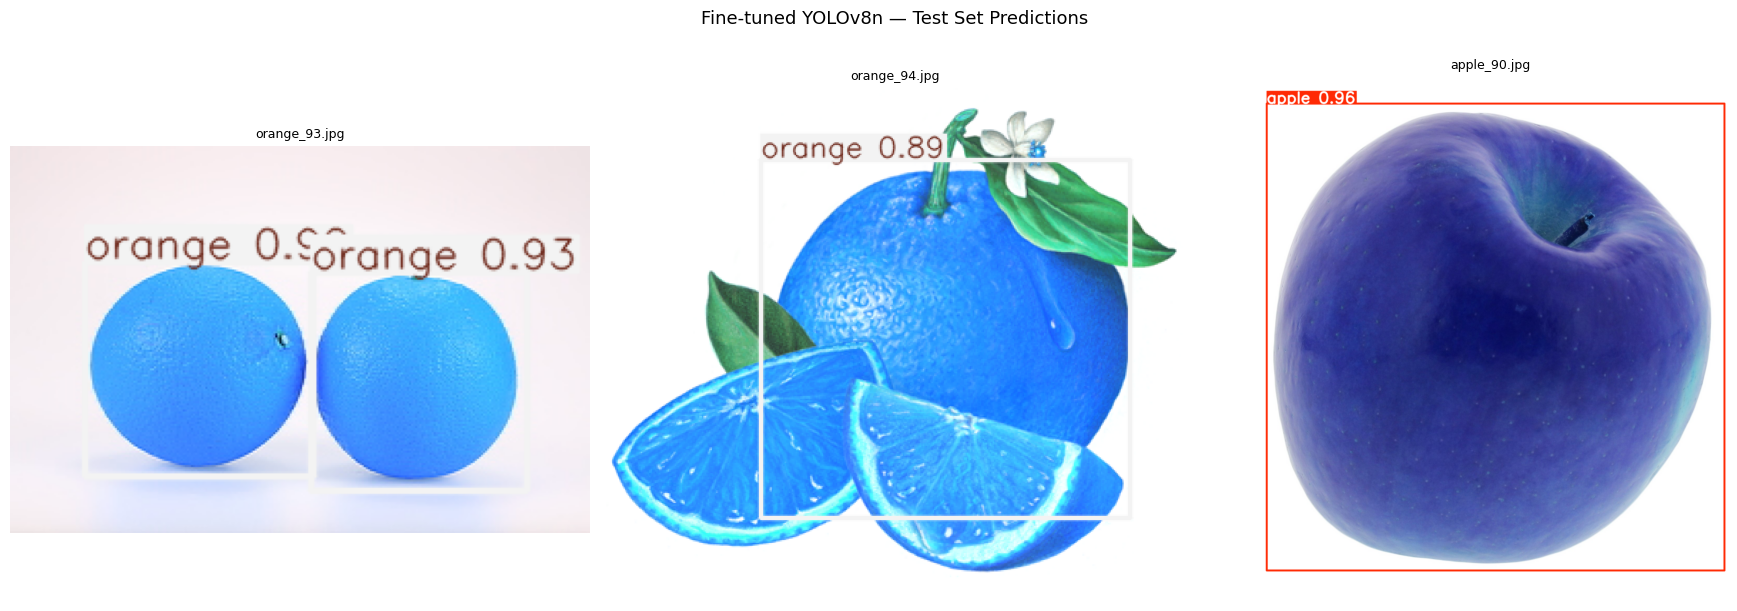

In [60]:
# Inference on 3 random test images
yolo_test_images = sorted(
    glob.glob(os.path.join(YOLO_ROOT, "val", "images", "*.jpg")) +
    glob.glob(os.path.join(YOLO_ROOT, "val", "images", "*.png"))
)
test_samples = random.sample(yolo_test_images, min(3, len(yolo_test_images)))

fig, axes = plt.subplots(1, len(test_samples), figsize=(6 * len(test_samples), 6))
if len(test_samples) == 1:
    axes = [axes]

for ax, img_path in zip(axes, test_samples):
    pred = finetuned_yolo.predict(img_path, conf=0.25, verbose=False)[0]
    vis  = pred.plot()   # returns RGB numpy array with boxes drawn
    ax.imshow(vis)
    ax.set_title(os.path.basename(img_path), fontsize=9)
    ax.axis("off")

plt.suptitle("Fine-tuned YOLOv8n — Test Set Predictions", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Step 7d — Comparison Table: Faster R-CNN vs YOLO (pre-trained) vs YOLO (fine-tuned)

In [61]:
N_RUNS    = 10
bench_img = test_samples[0]

# ── 1. Faster R-CNN inference time ──
bench_bgr    = cv2.imread(bench_img)
bench_rgb    = cv2.cvtColor(bench_bgr, cv2.COLOR_BGR2RGB)
bench_tensor = to_tensor_fn(bench_rgb).to(device)

_  = faster_rcnn_model([bench_tensor])          # warm-up
t0 = time.time()
with torch.no_grad():
    for _ in range(N_RUNS):
        faster_rcnn_model([bench_tensor])
frcnn_ms = (time.time() - t0) / N_RUNS * 1000

# ── 2. YOLO pre-trained ──
pretrained_yolo = YOLO("yolov8n.pt")
_  = pretrained_yolo.predict(bench_img, verbose=False)   # warm-up
t0 = time.time()
for _ in range(N_RUNS):
    pretrained_yolo.predict(bench_img, verbose=False)
yolo_pt_ms = (time.time() - t0) / N_RUNS * 1000

# ── 3. YOLO fine-tuned ──
_  = finetuned_yolo.predict(bench_img, verbose=False)    # warm-up
t0 = time.time()
for _ in range(N_RUNS):
    finetuned_yolo.predict(bench_img, verbose=False)
yolo_ft_ms = (time.time() - t0) / N_RUNS * 1000

# ── 4. YOLO pre-trained metrics on fruit test set ──
pt_metrics = pretrained_yolo.val(data=yaml_path, split="test", verbose=False)
pt_prec    = pt_metrics.box.mp
pt_rec     = pt_metrics.box.mr
pt_map50   = pt_metrics.box.map50
pt_map5095 = pt_metrics.box.map

print(f"Inference time ({N_RUNS}-run average):")
print(f"  Faster R-CNN     : {frcnn_ms:.1f} ms")
print(f"  YOLO pre-trained : {yolo_pt_ms:.1f} ms")
print(f"  YOLO fine-tuned  : {yolo_ft_ms:.1f} ms")

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2390.6±889.6 MB/s, size: 127.8 KB)
val: Scanning /content/yolo_dataset/val/labels.cache... 60 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 60/60 19.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.1it/s 3.5s
                   all         60        117      0.266      0.129      0.153     0.0998
Speed: 18.0ms preprocess, 7.4ms inference, 0.0ms loss, 3.5ms postprocess per image
Results saved to /content/runs/detect/val2
Inference time (10-run average):
  Faster R-CNN     : 119.0 ms
  YOLO pre-trained : 11.8 ms
  YOLO fine-tuned  : 11.5 ms


                           Model Inference Time (ms/img)  Precision     Recall     mAP@50  mAP@50-95
Faster R-CNN (pre-trained, COCO)                   119.0 N/A (COCO) N/A (COCO) N/A (COCO) N/A (COCO)
     YOLOv8n (pre-trained, COCO)                    11.8      0.266      0.129      0.153      0.100
     YOLOv8n (fine-tuned, Fruit)                    11.5      0.806      0.856      0.892      0.664


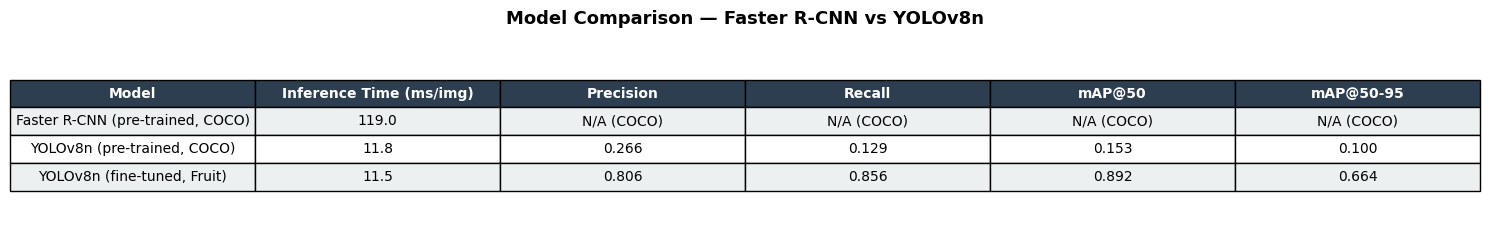

In [62]:
# Build and display comparison table
table = pd.DataFrame({
    "Model": [
        "Faster R-CNN (pre-trained, COCO)",
        "YOLOv8n (pre-trained, COCO)",
        "YOLOv8n (fine-tuned, Fruit)",
    ],
    "Inference Time (ms/img)": [
        f"{frcnn_ms:.1f}",
        f"{yolo_pt_ms:.1f}",
        f"{yolo_ft_ms:.1f}",
    ],
    "Precision":  ["N/A (COCO)", f"{pt_prec:.3f}",   f"{ft_prec:.3f}"],
    "Recall":     ["N/A (COCO)", f"{pt_rec:.3f}",    f"{ft_rec:.3f}"],
    "mAP@50":    ["N/A (COCO)", f"{pt_map50:.3f}",  f"{map50:.3f}"],
    "mAP@50-95": ["N/A (COCO)", f"{pt_map5095:.3f}",f"{map5095:.3f}"],
})

print(table.to_string(index=False))

# Rendered matplotlib table
fig, ax = plt.subplots(figsize=(15, 2.5))
ax.axis("off")
tbl = ax.table(
    cellText  = table.values,
    colLabels = table.columns,
    cellLoc   = "center",
    loc       = "center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.7)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2c3e50")
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 1:
        cell.set_facecolor("#ecf0f1")
plt.title("Model Comparison — Faster R-CNN vs YOLOv8n",
          fontsize=13, pad=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Summary

| | R-CNN | Fast R-CNN | Faster R-CNN | YOLO |
|---|---|---|---|---|
| **Region proposals** | Selective Search (external) | Selective Search (external) | RPN (internal, learned) | None |
| **CNN passes per image** | N (one per proposal) | 1 | 1 | 1 |
| **End-to-end trainable** | No | Mostly | Yes | Yes |
| **Speed** | Very slow | Faster | Fast | Fastest |

This lab demonstrated the complete evolution from the wasteful per-crop CNN passes of R-CNN, through the shared feature map of Fast R-CNN, the internal proposal network of Faster R-CNN, to YOLO's fully unified single-shot regression framework. Fine-tuning YOLO on domain-specific data (fruit images) consistently outperforms zero-shot COCO weights on in-distribution classes.